In [1]:
import json
from pathlib import Path

import numpy as np
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    classification_report,
    accuracy_score,
    confusion_matrix,
    r2_score,
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/treesat-maxblock10-bipool-99-99/"

Using device: cuda
Mounted at /content/drive


In [2]:
CHM_MIN_THRESHOLD = 1
configs = {
    # data
    'batch_size': 0,
    # training
    'model_type': '',
    'base_channels': 0,
    'hidden_dims': (),
    'epochs': 0,
    'patience': 0,
    'dropout': 0.0,
    'weight_decay': 0.0,
    'base_lr': 0.0,
    'max_lr': 0.0,
    'scheduler': None,
    # mtl
    'cls_weight': 0,
    'reg_weight': 0,
    'encoder_lr': 0.0,
    'cls_lr': 0.0,
    'reg_lr': 0.0
}


# I PREPARATION

## Load Data

In [3]:
class MultiTaskDataset(Dataset):
    """
    Dataset for multi-task learning with SAR and CHM targets.
    """
    def __init__(self, images: np.ndarray, labels: np.ndarray):
        super().__init__()
        inputs = images[:, 0:3, ...].astype(np.float32) # band VV, VH, VV/VH, 0-2
        self.inputs = torch.from_numpy(inputs)
        chm = images[:, 3, ...].astype(np.float32) # band CHM, 3
        mask_invalid = (chm < CHM_MIN_THRESHOLD)
        chm[mask_invalid] = np.nan
        self.chm_targets = torch.from_numpy(chm).unsqueeze(1)

        labels_arr = np.asarray(labels).astype(np.float32)
        if labels_arr.ndim != 2:
            raise ValueError(f"Expected labels of shape (N, 15) for multi-label, got {labels_arr.shape}")
        self.cls_targets = torch.from_numpy(labels_arr)

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        x = self.inputs[idx]
        y_cls = self.cls_targets[idx]
        y_chm = self.chm_targets[idx]
        return x, y_cls, y_chm

def make_datasets(data_dir):
    data_dir = Path(data_dir)

    train_images = np.load(data_dir / "train_x.npy")
    train_labels = np.load(data_dir / "train_y.npy")
    val_images = np.load(data_dir / "val_x.npy")
    val_labels = np.load(data_dir / "val_y.npy")
    test_images = np.load(data_dir / "test_x.npy")
    test_labels = np.load(data_dir / "test_y.npy")

    train_ds = MultiTaskDataset(train_images, train_labels)
    val_ds = MultiTaskDataset(val_images, val_labels)
    test_ds = MultiTaskDataset(test_images, test_labels)

    print(f"Images loaded: train-{len(train_ds)}", f"test-{len(test_ds)}", f"val-{len(val_ds)}")
    return train_ds, val_ds, test_ds

In [ ]:
train_ds, val_ds, test_ds = make_datasets(BASE_DIR)
configs.update(batch_size=64, loss_fn="class_weights_inv_sqrt_freq_normalized")
train_loader = DataLoader(train_ds, batch_size=configs["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=configs["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=configs["batch_size"], shuffle=False, num_workers=2)

with Path(f"{BASE_DIR}/classes.json").open("r") as f:
    classes = json.load(f)
with Path(f"{BASE_DIR}/class_weights.json").open("r") as f:
    cw = json.load(f)

class_weights = torch.tensor(cw[configs["loss_fn"]], dtype=torch.float32)
num_classes = len(classes)

## Model - MTL

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int, padding: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int) -> None:
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=kernel_size,
            stride=stride,
        )
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

In [6]:
class MultiTaskUNet(nn.Module):
    """
    - Encoder 1: DoubleConv, no downsample (B, C, H, W) -> (B, base, H, W)
    - Encoder 2: DoubleConv then downsample (B, base, H, W) -> (B, 2*base, H/2, W/2)
    - Bottleneck: DoubleConv then downsample (B, 2*base, H/2, W/2) -> (B, 4*base, H/6, W/6)
    - Classification Head: Global Average Pooling then Linear (B, 4*base, H/6, W/6) -> (B, num_classes)
    - Decoder 2: upsample and concat with skip (B, 4*base, H/6, W/6) -> (B, 2*base, H/2, W/2)
    - Decoder 1: upsample and concat with skip (B, 2*base, H/2, W/2) -> (B, base, H, W)
    - Output Conv: maps features to CHM prediction (B, base, H, W) -> (B, 1, H, W)
    """
    def __init__(self, in_channels: int, num_classes: int, base_channels: int = 32, dropout: float = 0.3) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.down1 = Down(
            in_channels=base_channels * 2,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=2,
            padding=1,
        )
        self.bottleneck = DoubleConv(base_channels * 2, base_channels * 4)
        self.down2 = Down(
            in_channels=base_channels * 4,
            out_channels=base_channels * 4,
            kernel_size=3,
            stride=3,
            padding=0,
        )

        self.global_pool_cls = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Linear(base_channels * 4, num_classes)

        self.up2_reg = Up(
            in_channels=base_channels * 4,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=3,
        )
        self.dropout2_reg = nn.Dropout2d(p=dropout)
        self.up1_reg = Up(
            in_channels=base_channels * 2,
            out_channels=base_channels,
            kernel_size=2,
            stride=2,
        )
        self.out_conv_reg = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.down1(x2)
        x4 = self.bottleneck(x3)
        x5 = self.down2(x4)

        feats_cls = self.global_pool_cls(x5)
        feats_cls = feats_cls.view(feats_cls.size(0), -1)
        logits = self.cls_head(feats_cls)

        xr = self.up2_reg(x5, x3)
        xr = self.dropout2_reg(xr)
        xr = self.up1_reg(xr, x1)
        raw_chm = self.out_conv_reg(xr)
        chm = F.softplus(raw_chm)

        return logits, chm

In [7]:
class CrossTaskAttention(nn.Module):
    def __init__(self, channels: int, num_heads: int = 4) -> None:
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.attn_cls = nn.MultiheadAttention(embed_dim=channels, num_heads=num_heads, batch_first=True)
        self.attn_reg = nn.MultiheadAttention(embed_dim=channels, num_heads=num_heads, batch_first=True)
        self.norm_cls = nn.LayerNorm(channels)
        self.norm_reg = nn.LayerNorm(channels)

    def forward(self, feat_cls: torch.Tensor, feat_reg: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        n, c, h, w = feat_cls.shape
        cls_tokens = feat_cls.view(n, c, h * w).transpose(1, 2)
        reg_tokens = feat_reg.view(n, c, h * w).transpose(1, 2)

        cls_q = self.norm_cls(cls_tokens)
        reg_q = self.norm_reg(reg_tokens)

        cls_attended, _ = self.attn_cls(query=cls_q, key=reg_q, value=reg_q, need_weights=False)
        reg_attended, _ = self.attn_reg(query=reg_q, key=cls_q, value=cls_q, need_weights=False)
        cls_tokens = cls_tokens + cls_attended
        reg_tokens = reg_tokens + reg_attended

        feat_cls_out = cls_tokens.transpose(1, 2).view(n, c, h, w)
        feat_reg_out = reg_tokens.transpose(1, 2).view(n, c, h, w)
        return feat_cls_out, feat_reg_out

class MultiTaskUNetCrossAttention(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, base_channels: int = 32, dropout: float = 0.3, attn_heads: int = 4) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.down1 = Down(in_channels=base_channels * 2, out_channels=base_channels * 2, kernel_size=3, stride=2, padding=1)
        self.bottleneck_shared = DoubleConv(base_channels * 2, base_channels * 4)
        self.down2 = Down(in_channels=base_channels * 4, out_channels=base_channels * 4, kernel_size=3, stride=3, padding=0)
        self.bottleneck_cls = DoubleConv(base_channels * 4, base_channels * 4)
        self.bottleneck_reg = DoubleConv(base_channels * 4, base_channels * 4)
        self.cross_attn = CrossTaskAttention(channels=base_channels * 4, num_heads=attn_heads)
        self.global_pool_cls = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Linear(base_channels * 4, num_classes)
        self.up2_reg = Up(in_channels=base_channels * 4, out_channels=base_channels * 2, kernel_size=3, stride=3)
        self.dropout2_reg = nn.Dropout2d(p=dropout)
        self.up1_reg = Up(in_channels=base_channels * 2, out_channels=base_channels, kernel_size=2, stride=2)
        self.out_conv_reg = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.down1(x2)
        x4 = self.bottleneck_shared(x3)
        x5 = self.down2(x4)
        b_cls = self.bottleneck_cls(x5)
        b_reg = self.bottleneck_reg(x5)
        b_cls, b_reg = self.cross_attn(b_cls, b_reg)
        feats_cls = self.global_pool_cls(b_cls)
        feats_cls = feats_cls.view(feats_cls.size(0), -1)
        logits = self.cls_head(feats_cls)
        xr = self.up2_reg(b_reg, x3)
        xr = self.dropout2_reg(xr)
        xr = self.up1_reg(xr, x1)
        raw_chm = self.out_conv_reg(xr)
        chm = F.softplus(raw_chm)
        return logits, chm



In [54]:

class CrossStitchUnit(nn.Module):
    def __init__(self, init_diag: float = 0.9, init_offdiag: float = 0.1) -> None:
        super().__init__()
        A = torch.tensor(
            [[init_diag, init_offdiag], [init_offdiag, init_diag]], dtype=torch.float32
        )
        self.alpha = nn.Parameter(A)

    def forward(self, f_cls: torch.Tensor, f_reg: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        a11, a12 = self.alpha[0, 0], self.alpha[0, 1]
        a21, a22 = self.alpha[1, 0], self.alpha[1, 1]
        f_cls_new = a11 * f_cls + a12 * f_reg
        f_reg_new = a21 * f_cls + a22 * f_reg
        return f_cls_new, f_reg_new


class MultiTaskUNetCrossStitch(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, base_channels: int = 32, dropout: float = 0.3) -> None:
        super().__init__()
        self.num_classes = num_classes

        self.enc_shared = DoubleConv(in_channels, base_channels)

        self.enc2_cls = DoubleConv(base_channels, base_channels * 2)
        self.down1_cls = Down(
            in_channels=base_channels * 2,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=2,
            padding=1,
        )
        self.bottleneck_cls = DoubleConv(base_channels * 2, base_channels * 4)
        self.down2_cls = Down(
            in_channels=base_channels * 4,
            out_channels=base_channels * 4,
            kernel_size=3,
            stride=3,
            padding=0,
        )

        self.enc2_reg = DoubleConv(base_channels, base_channels * 2)
        self.down1_reg = Down(
            in_channels=base_channels * 2,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=2,
            padding=1,
        )
        self.bottleneck_reg = DoubleConv(base_channels * 2, base_channels * 4)
        self.down2_reg = Down(
            in_channels=base_channels * 4,
            out_channels=base_channels * 4,
            kernel_size=3,
            stride=3,
            padding=0,
        )

        # Cross-Stitch units at multiple depths (after enc2, after down1, after bottleneck)
        self.cs_enc2 = CrossStitchUnit()
        self.cs_down1 = CrossStitchUnit()
        self.cs_bottleneck = CrossStitchUnit()

        # Classification head on deepest cls features
        self.global_pool_cls = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Linear(base_channels * 4, num_classes)

        self.up2_reg = Up(
            in_channels=base_channels * 4,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=3,
        )
        self.dropout2_reg = nn.Dropout2d(p=dropout)
        self.up1_reg = Up(
            in_channels=base_channels * 2,
            out_channels=base_channels,
            kernel_size=2,
            stride=2,
        )
        self.out_conv_reg = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x_shared = self.enc_shared(x)  # (B, base, H, W)

        x1_cls = x_shared
        x1_reg = x_shared

        # enc2
        x2_cls = self.enc2_cls(x1_cls)
        x2_reg = self.enc2_reg(x1_reg)
        x2_cls, x2_reg = self.cs_enc2(x2_cls, x2_reg)

        # down1
        x3_cls = self.down1_cls(x2_cls)
        x3_reg = self.down1_reg(x2_reg)
        x3_cls, x3_reg = self.cs_down1(x3_cls, x3_reg)

        # bottleneck
        x4_cls = self.bottleneck_cls(x3_cls)
        x4_reg = self.bottleneck_reg(x3_reg)
        x4_cls, x4_reg = self.cs_bottleneck(x4_cls, x4_reg)

        x5_cls = self.down2_cls(x4_cls)
        x5_reg = self.down2_reg(x4_reg)

        feats_cls = self.global_pool_cls(x5_cls)
        feats_cls = feats_cls.view(feats_cls.size(0), -1)
        logits = self.cls_head(feats_cls)

        xr = self.up2_reg(x5_reg, x3_reg)
        xr = self.dropout2_reg(xr)
        xr = self.up1_reg(xr, x1_reg)
        raw_chm = self.out_conv_reg(xr)
        chm = F.softplus(raw_chm)

        return logits, chm

## Functions

### Loss Function

In [8]:
def masked_rmse_loss(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    mask = ~torch.isnan(targets)
    if not mask.any():
        return (preds * 0.0).sum()
    diff = preds[mask] - targets[mask]
    return torch.sqrt(torch.mean(diff ** 2))

### Training Function

In [9]:
def train_one_epoch(model, loader, cls_criterion, reg_criterion, optimizer, device, epoch=None, lr_history=None, scheduler=None, cls_weight: float = 1.0, reg_weight: float = 1.0, log_vars: torch.Tensor | None = None,)-> tuple[float, float, float]:
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_reg_loss = 0.0
    total_samples = 0

    # Running means of per-batch losses for each task (over this epoch)
    running_mean_cls = 0.0
    running_mean_reg = 0.0
    num_batches = 0

    for images, labels_cls, labels_chm in tqdm(
        loader, desc=f"Train {epoch}" if epoch is not None else "Train"
    ):
        images = images.to(device)
        labels_cls = labels_cls.to(device)
        labels_chm = labels_chm.to(device)

        optimizer.zero_grad()
        logits, chm_pred = model(images)

        loss_cls = cls_criterion(logits, labels_cls)
        loss_reg = reg_criterion(chm_pred, labels_chm)

        num_batches += 1
        running_mean_cls = (running_mean_cls * (num_batches - 1) + loss_cls.item()) / num_batches
        running_mean_reg = (running_mean_reg * (num_batches - 1) + loss_reg.item()) / num_batches

        # per-task normalization by its own running mean
        mean_cls = torch.tensor(running_mean_cls, device=loss_cls.device)
        mean_reg = torch.tensor(running_mean_reg, device=loss_reg.device)
        norm_cls = loss_cls / mean_cls
        norm_reg = loss_reg / mean_reg

        # uncertainty weighting
        if log_vars is not None:
            s = log_vars
            base = 0.0 * norm_cls
            # i = 0 -> classification, i = 1 -> regression
            for i in range(2):
                weight_i = 0.5 * torch.exp(-s[i])
                if i == 0:
                    base = base + weight_i * norm_cls + 0.5 * s[i]
                else:
                    base = base + weight_i * norm_reg + 0.5 * s[i]
            loss = base
        else:
            loss = cls_weight * norm_cls + reg_weight * norm_reg

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        if lr_history is not None:
            lr_history.append(optimizer.param_groups[0]["lr"])

        batch_size = images.size(0)
        total_loss += float(loss.item()) * batch_size
        total_cls_loss += float(loss_cls.item()) * batch_size
        total_reg_loss += float(loss_reg.item()) * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    avg_cls_loss = total_cls_loss / max(total_samples, 1)
    avg_reg_loss = total_reg_loss / max(total_samples, 1)
    return avg_loss, avg_cls_loss, avg_reg_loss

def evaluate(model, loader, cls_criterion, reg_criterion, device, desc: str = "Eval", cls_weight: float = 1.0, reg_weight: float = 1.0, log_vars: torch.Tensor | None = None):
    model.eval()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_reg_loss = 0.0
    total_samples = 0

    running_mean_cls = 0.0
    running_mean_reg = 0.0
    num_batches = 0

    all_true_cls = []   # multi-hot ground truth
    all_pred_cls = []   # multi-hot predictions (after threshold)
    all_logits_cls = [] # raw logits
    all_true_chm = []
    all_pred_chm = []

    with torch.no_grad():
        for images, labels_cls, labels_chm in tqdm(loader, desc=desc):
            images = images.to(device)
            labels_cls = labels_cls.to(device)
            labels_chm = labels_chm.to(device)

            logits, chm_pred = model(images)

            # raw per-task losses
            loss_cls = cls_criterion(logits, labels_cls)
            loss_reg = reg_criterion(chm_pred, labels_chm)

            # update simple running means (no EMA) using current batch losses
            num_batches += 1
            running_mean_cls = (running_mean_cls * (num_batches - 1) + loss_cls.item()) / num_batches
            running_mean_reg = (running_mean_reg * (num_batches - 1) + loss_reg.item()) / num_batches

            # per-task normalization by its own running mean
            mean_cls = torch.tensor(running_mean_cls, device=loss_cls.device)
            mean_reg = torch.tensor(running_mean_reg, device=loss_reg.device)
            norm_cls = loss_cls / mean_cls
            norm_reg = loss_reg / mean_reg

            # uncertainty weighting
            if log_vars is not None:
                s = log_vars
                base = 0.0 * norm_cls
                for i in range(2):
                    weight_i = 0.5 * torch.exp(-s[i])
                    if i == 0:
                        base = base + weight_i * norm_cls + 0.5 * s[i]
                    else:
                        base = base + weight_i * norm_reg + 0.5 * s[i]
                loss = base
            else:
                loss = cls_weight * norm_cls + reg_weight * norm_reg

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_cls_loss += float(loss_cls.item()) * batch_size
            total_reg_loss += float(loss_reg.item()) * batch_size
            total_samples += batch_size

            # classification predictions
            probs = torch.sigmoid(logits)
            preds_cls = (probs >= 0.5).float()

            all_true_cls.append(labels_cls.cpu().numpy())
            all_pred_cls.append(preds_cls.cpu().numpy())
            all_logits_cls.append(logits.cpu().numpy())

            # regression targets/predictions for valid CHM pixels
            mask = ~torch.isnan(labels_chm)
            if mask.any():
                all_true_chm.append(labels_chm[mask].cpu().numpy())
                all_pred_chm.append(chm_pred[mask].cpu().numpy())

    avg_loss = total_loss / max(total_samples, 1)
    avg_cls_loss = total_cls_loss / max(total_samples, 1)
    avg_reg_loss = total_reg_loss / max(total_samples, 1)

    # classification metrics
    y_true_cls = np.concatenate(all_true_cls, axis=0) if all_true_cls else np.array([])
    y_pred_cls = np.concatenate(all_pred_cls, axis=0) if all_pred_cls else np.array([])
    y_logits = np.concatenate(all_logits_cls, axis=0) if all_logits_cls else np.array([])

    if y_true_cls.size > 0:
        y_scores = torch.sigmoid(torch.from_numpy(y_logits)).numpy()
        f1_micro = f1_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        f1_weighted = f1_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        precision_micro = precision_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        precision_weighted = precision_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        recall_micro = recall_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        recall_weighted = recall_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        map_micro = average_precision_score(y_true_cls, y_scores, average="micro")
        map_weighted = average_precision_score(y_true_cls, y_scores, average="weighted")
        accuracy = accuracy_score(y_true_cls, y_pred_cls)
    else:
        f1_micro = f1_weighted = precision_micro = precision_weighted = float("nan")
        recall_micro = recall_weighted = map_micro = map_weighted = float("nan")
        accuracy = float("nan")

    # Regression metrics
    if all_true_chm:
        y_true_chm_np = np.concatenate(all_true_chm, axis=0).reshape(-1)
        y_pred_chm_np = np.concatenate(all_pred_chm, axis=0).reshape(-1)

        y_true_chm_t = torch.from_numpy(y_true_chm_np)
        y_pred_chm_t = torch.from_numpy(y_pred_chm_np)
        rmse = float(masked_rmse_loss(y_pred_chm_t, y_true_chm_t).item())
        r2 = float(r2_score(y_true_chm_np, y_pred_chm_np))
    else:
        rmse = float("nan")
        r2 = float("nan")

    metrics = {
        "loss": avg_loss,
        "cls_loss": avg_cls_loss,
        "reg_loss": avg_reg_loss,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "precision_micro": precision_micro,
        "precision_weighted": precision_weighted,
        "recall_micro": recall_micro,
        "recall_weighted": recall_weighted,
        "map_micro": map_micro,
        "map_weighted": map_weighted,
        "accuracy": accuracy,
        "rmse": rmse,
        "r2": r2,
    }

    return metrics, y_true_cls, y_pred_cls

In [11]:
def build_mtl_unet_param_groups(model, encoder_lr: float, cls_lr: float, reg_lr: float, weight_decay: float):
    return None
#     if isinstance(model, MultiTaskUNetCrossAttention):
#         encoder_modules = [
#             model.enc1, model.enc2, model.down1, model.bottleneck_shared,
#             model.down2, model.bottleneck_cls, model.bottleneck_reg, model.cross_attn,
#         ]
#         cls_modules = [model.global_pool_cls, model.cls_head]
#         reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
#     elif isinstance(model, MultiTaskUNet):
#         encoder_modules = [model.enc1, model.enc2, model.down1, model.down2, model.bottleneck]
#         cls_modules = [model.global_pool_cls, model.cls_head]
#         reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]

#     encoder_params = collect_params(encoder_modules)
#     cls_params = collect_params(cls_modules)
#     reg_params = collect_params(reg_modules)
#     return [
#         {"params": encoder_params, "lr": encoder_lr, "weight_decay": weight_decay},
#         {"params": cls_params, "lr": cls_lr, "weight_decay": weight_decay},
#         {"params": reg_params, "lr": reg_lr, "weight_decay": weight_decay},
    # ]

def collect_params(modules):
    params = []
    for m in modules:
        params.extend(list(m.parameters()))
    return params

### Visualization

#### cm

In [12]:
def plot_cm(model):
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for images, labels_cls, _ in tqdm(test_loader, desc="Test features for confusion"):
            images = images.to(device)
            out = model(images)
            if isinstance(out, tuple):
                logits = out[0]
            else:
                logits = out
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels_cls.numpy())

    X_logits = np.concatenate(all_logits, axis=0)
    y_true_multi_full = np.concatenate(all_labels, axis=0)

    y_true_dom = y_true_multi_full.argmax(axis=1)
    y_scores_full = 1.0 / (1.0 + np.exp(-X_logits))
    y_pred_dom = y_scores_full.argmax(axis=1)

    cm_dom = confusion_matrix(y_true_dom, y_pred_dom, labels=np.arange(num_classes))

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        cm_dom,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted dominant class")
    plt.ylabel("True dominant class")
    plt.tight_layout()
    plt.show()

#### plot samples

In [13]:
def visualize_chm_s1_samples(model, dataset, start_idx: int = 0, num_samples: int = 4) -> None:
    model.eval()

    start_idx = int(start_idx)
    num_samples = int(num_samples)
    end_idx = min(start_idx + num_samples, len(dataset))
    if end_idx <= start_idx:
        print("No samples to visualize.")
        return

    n = end_idx - start_idx

    inputs = dataset.inputs[start_idx:end_idx].to(device)
    targets = dataset.chm_targets[start_idx:end_idx]

    with torch.no_grad():
        out = model(inputs)
        if isinstance(out, tuple):
            _, preds = out
        else:
            preds = out

    inputs_np = inputs.cpu().numpy()
    targets_np = targets.cpu().numpy()[:, 0, :, :]
    preds_np = preds.cpu().numpy()[:, 0, :, :]
    s1_list = []   # (n, 3, H, W)
    chm_list = []  # (n, 2, H, W)

    for row in range(n):
        band1 = inputs_np[row, 0, :, :]
        band2 = inputs_np[row, 1, :, :]
        if inputs_np.shape[1] > 2:
            band3 = inputs_np[row, 2, :, :]
        else:
            denom = np.where(np.abs(band2) < 1e-6, 1e-6, band2)
            band3 = band1 / denom
        chm_true = targets_np[row]
        chm_pred = preds_np[row]

        s1_list.append(np.stack([band1, band2, band3], axis=0))
        chm_list.append(np.stack([chm_true, chm_pred], axis=0))

    fig, axes = plt.subplots(nrows=n, ncols=5, figsize=(3 * 5, 2.5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row in range(n):
        row_axes = axes[row]
        band1, band2, band3 = s1_list[row]
        chm_true, chm_pred = chm_list[row]

        images = [band1, band2, band3, chm_true, chm_pred]
        titles = ["VV", "VH", "VV/VH", "CHM true", "CHM pred"]

        chm_combined = np.concatenate([chm_true, chm_pred])
        vmin_chm = float(np.nanmin(chm_combined))
        vmax_chm = float(np.nanmax(chm_combined))
        if not np.isfinite(vmin_chm) or not np.isfinite(vmax_chm):
            vmin_chm, vmax_chm = 0.0, 1.0

        for col in range(5):
            ax = row_axes[col]
            band = images[col]
            cmap = "gray" if col < 3 else "viridis"

            im = ax.imshow(band, cmap=cmap)
            if row < 1:
                ax.set_title(titles[col])
            ax.axis("off")

            if col < 3:
                curr_vmin = float(np.nanmin(band))
                curr_vmax = float(np.nanmax(band))
                if not np.isfinite(curr_vmin) or not np.isfinite(curr_vmax):
                    curr_vmin, curr_vmax = 0.0, 1.0
            else:
                curr_vmin, curr_vmax = vmin_chm, vmax_chm

            im.set_clim(curr_vmin, curr_vmax)

            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            ticks = np.linspace(curr_vmin, curr_vmax, 5)
            cbar.set_ticks(ticks)
            cbar.ax.tick_params(labelsize=9)
            cbar.ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, _: f"{x:.1f}" if x < 1 else f"{int(x)}")
            )

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1, wspace=0.3)
    plt.show()

#### scatter plot

In [14]:
def collect_regression_pairs(model, loader=None, device=None):
    if loader is None:
        loader = test_loader
    if device is None:
        dev = globals().get("device", "cpu")
    else:
        dev = device

    model.eval()
    ys = []
    ps = []
    with torch.no_grad():
        for images, labels_cls, labels_chm in tqdm(loader, desc="Collect reg pairs"):
            images = images.to(dev)
            targets = labels_chm.to(dev)
            out = model(images)
            if isinstance(out, tuple):
                _, preds = out
            else:
                preds = out
            mask = torch.isfinite(targets)
            if mask.any():
                ys.append(targets[mask].detach().cpu().numpy())
                ps.append(preds[mask].detach().cpu().numpy())
    if not ys:
        return np.empty(0, dtype=np.float32), np.empty(0, dtype=np.float32)
    y_true = np.concatenate(ys, axis=0)
    y_pred = np.concatenate(ps, axis=0)
    return y_true, y_pred


def plot_regression_joint_with_hists(
    y_true,
    y_pred,
    xlabel="True CHM",
    ylabel="Predicted CHM",
    max_value=50,
    bins: int = 40,
):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if max_value is not None:
        mask &= y_true <= max_value
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if y_true.size == 0:
        print("No valid data to plot.")
        return

    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    t_mean = float(y_true.mean())
    ss_res = float(np.sum((y_pred - y_true) ** 2))
    ss_tot = float(np.sum((y_true - t_mean) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    fig = plt.figure(figsize=(6, 6))
    gs = fig.add_gridspec(2, 2, width_ratios=(4, 0.8), height_ratios=(0.8, 4), wspace=0.05, hspace=0.05)

    ax_histx = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_histx.hist(y_true, bins=bins, color="#1f77b4")
    ax_histx.hist(y_true, bins=bins, color="#1f77b4", edgecolor="black", linewidth=0.5)
    ax_histx.set_ylabel("Count")
    ax_histx.tick_params(labelbottom=False)
    ax_histx.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    ax_histy.hist(y_pred, bins=bins, orientation="horizontal", color="#1f77b4", edgecolor="black", linewidth=0.5)
    ax_histy.tick_params(labelleft=False)
    ax_histy.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    if max_value is None:
        min_plot = 0.0
        max_plot = max(float(y_true.max()), float(y_pred.max()))
    else:
        min_plot = 0.0
        max_plot = float(max_value)
        ax_histx.set_xlim(min_plot, max_plot)
        ax_histy.set_ylim(min_plot, max_plot)

    ax_joint.hexbin(y_true, y_pred, gridsize=200, cmap="turbo", mincnt=1)
    ax_joint.plot([min_plot, max_plot], [min_plot, max_plot], linestyle="--", color="k", linewidth=1.0)
    ax_joint.set_xlim(min_plot, max_plot)
    ax_joint.set_ylim(min_plot, max_plot)
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_ylabel(ylabel)
    ax_joint.text(0.5, 0.95, f"R² = {r2:.3f}, RMSE = {rmse:.3f}", transform=ax_joint.transAxes, ha="center", va="top")

    if max_value is None:
        min_plot = 0.0
        max_plot = max(float(y_true.max()), float(y_pred.max()))
    else:
        min_plot = 0.0
        max_plot = float(max_value)
        ax_histx.set_xlim(min_plot, max_plot)
        ax_histy.set_ylim(min_plot, max_plot)

    slope, intercept = np.polyfit(y_true, y_pred, 1)
    x_line = np.linspace(min_plot, max_plot, 100)
    y_reg = slope * x_line + intercept

    ax_joint.hexbin(y_true, y_pred, gridsize=200, cmap="turbo", mincnt=1)
    ax_joint.plot([min_plot, max_plot], [min_plot, max_plot], linestyle="--", color="k", linewidth=1.0)
    ax_joint.plot(x_line, y_reg, linestyle="--", color="red", linewidth=1.0)

    plt.show()

#### curve

In [15]:
def plot_curves(history, task="reg"):
    if task == "cls" or task == "mtl":
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ax = axes[0]
    ax.plot(history["epoch"], history["train_loss"], label="train_loss")
    ax.plot(history["epoch"], history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_title("Train Curve")
    ax.legend(fontsize=7)
    ax.grid(True)

    ax = axes[1]
    ax.plot(history["lr"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Learning rate")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_title("Learning Rate Schedule")
    ax.grid(True)

    if task == "cls" or task == "mtl":
        ax = axes[2]
        ax.plot(history["epoch"], history["val_accuracy"], label="val_accuracy")
        ax.plot(history["epoch"], history["val_accuracy"], label="val_accuracy")
        ax.plot(history["epoch"], history["val_f1_micro"], label="val_f1_micro")
        ax.plot(history["epoch"], history["val_precision_micro"], label="val_precision_micro")
        ax.plot(history["epoch"], history["val_recall_micro"], label="val_recall_micro")
        ax.plot(history["epoch"], history["val_map_micro"], label="val_map_micro")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=6)
        ax.grid(True)
        ax.set_title("Train Curve")

    plt.tight_layout()
    plt.show()

    if task == "mtl":
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ax = axes[0]
        ax.plot(history["epoch"], history["train_cls_loss"], label="train_cls_loss")
        ax.plot(history["epoch"], history["val_cls_loss"], label="val_cls_loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Classification loss")
        ax.grid(True)
        ax.set_title("Classification Loss Curves (MTL)")
        ax.legend(fontsize=7)
        plt.tight_layout()

        ax = axes[1]
        ax.plot(history["epoch"], history["train_reg_loss"], label="train_reg_loss")
        ax.plot(history["epoch"], history["val_reg_loss"], label="val_reg_loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Regression loss")
        ax.grid(True)
        ax.set_title("Regression Loss Curves (MTL)")
        ax.legend(fontsize=7)
        plt.tight_layout()

        ax = axes[2]
        ax.plot(history["epoch"], history["w_cls"], label="weight_cls")
        ax.plot(history["epoch"], history["w_reg"], label="weight_reg")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Task weight")
        ax.grid(True)
        ax.set_title("Task Weight Curves")
        ax.legend(fontsize=7)
        plt.tight_layout()
        plt.show()

#### cos gradient

In [82]:
def _extract_encoder_grads(model) -> dict[str, torch.Tensor | None]:
    def _flatten(params: list[torch.nn.Parameter]) -> torch.Tensor | None:
        grads = [p.grad.view(-1) for p in params if p.grad is not None]
        if not grads:
            return None
        return torch.cat(grads)

    if isinstance(model, MultiTaskUNet):
        # Shared encoder: enc1, enc2, down1, bottleneck, down2
        params_enc1 = list(model.enc1.parameters())
        params_enc2 = list(model.enc2.parameters()) + list(model.down1.parameters())
        params_bottleneck = list(model.bottleneck.parameters()) + list(model.down2.parameters())

    elif isinstance(model, MultiTaskUNetCrossAttention):
        # Shared encoder with task-specific bottlenecks at deepest level
        params_enc1 = list(model.enc1.parameters())
        params_enc2 = list(model.enc2.parameters()) + list(model.down1.parameters())
        params_bottleneck = (
            list(model.bottleneck_shared.parameters())
            + list(model.down2.parameters())
            + list(model.bottleneck_cls.parameters())
            + list(model.bottleneck_reg.parameters())
        )

    elif isinstance(model, MultiTaskUNetCrossStitch):
        params_enc1 = list(model.enc_shared.parameters())
        params_enc2 = (
            list(model.enc2_cls.parameters())
            + list(model.enc2_reg.parameters())
            + list(model.down1_cls.parameters())
            + list(model.down1_reg.parameters())
            + list(model.cs_enc2.parameters())
            + list(model.cs_down1.parameters())
        )
        params_bottleneck = (
            list(model.bottleneck_cls.parameters())
            + list(model.bottleneck_reg.parameters())
            + list(model.down2_cls.parameters())
            + list(model.down2_reg.parameters())
            + list(model.cs_bottleneck.parameters())
        )

    grads: dict[str, torch.Tensor | None] = {}
    grads["enc1"] = _flatten(params_enc1)
    grads["enc2"] = _flatten(params_enc2)
    grads["bottleneck"] = _flatten(params_bottleneck)
    return grads


def compute_encoder_grad_cosines(model: nn.Module, images: torch.Tensor, labels_cls: torch.Tensor, labels_chm: torch.Tensor, cls_criterion, reg_criterion, device: str) -> dict[str, float]:
    model.zero_grad()
    images = images.to(device)
    labels_cls = labels_cls.to(device)
    labels_chm = labels_chm.to(device)

    logits, chm_pred = model(images)
    loss_cls = cls_criterion(logits, labels_cls)
    loss_reg = reg_criterion(chm_pred, labels_chm)

    # Gradients for classification loss
    loss_cls.backward(retain_graph=True)
    grads_cls = _extract_encoder_grads(model)

    # Gradients for regression loss
    model.zero_grad()
    loss_reg.backward()
    grads_reg = _extract_encoder_grads(model)

    cosines: dict[str, float] = {}
    eps = 1e-8
    for key in grads_cls.keys():
        g_cls = grads_cls[key]
        g_reg = grads_reg[key]
        if g_cls is None or g_reg is None:
            cos = 0.0
        else:
            num = torch.dot(g_cls, g_reg)
            den = g_cls.norm() * g_reg.norm() + eps
            cos = float((num / den).item())
        cosines[key] = cos

    return cosines


def plot_grad_cosines(grad_history):
    if not grad_history["epoch"]:
        return

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(grad_history["epoch"], grad_history["cos_enc1"], label="enc1")
    ax.plot(grad_history["epoch"], grad_history["cos_enc2"], label="enc2")
    ax.plot(grad_history["epoch"], grad_history["cos_bottleneck"], label="bottleneck")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cosine similarity (cls vs reg)")
    ax.set_title("Encoder Gradient Cosine Similarity (MTL)")
    ax.legend(fontsize=7)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

#### evaluation

In [17]:
def inference_mtl(model, best_state, train_loader=train_loader, val_loader=val_loader, test_loader=test_loader, cls_criterion=None, reg_criterion=None, device=device):
    if best_state is not None:
        model.load_state_dict(best_state)
    test_metrics, test_true, test_pred = evaluate(model, test_loader, cls_criterion, reg_criterion, device, desc="Test Eval",
                                                  cls_weight=configs["cls_weight"], reg_weight=configs["reg_weight"])
    print(
        "test loss: ", f"{test_metrics['loss']:.4f}",
        "\ncls loss: ", f"{test_metrics['cls_loss']:.4f}",
        "\nreg loss: ", f"{test_metrics['reg_loss']:.4f}",
        "\nr2: ", f"{test_metrics['r2']:.4f}"
        )
    print("\n", classification_report(test_true, test_pred, zero_division=0, target_names=classes))
    print(
        "\t | micro\t | weighted\t \n",
        "-------", "|", "-------------", "|","-------------",
        f"\nprecision| {test_metrics['precision_micro']*100:.3f}%\t | {test_metrics['precision_weighted']*100:.3f}%\t",
        f"\nrecall\t | {test_metrics['recall_micro']*100:.3f}%\t | {test_metrics['recall_weighted']*100:.3f}%\t"
        f"\nf1\t | {test_metrics['f1_micro']*100:.3f}%\t | {test_metrics['f1_weighted']*100:.3f}%\t"
        f"\nmap\t | {test_metrics['map_micro']*100:.3f}%\t | {test_metrics['map_weighted']*100:.3f}%\t"
        f"\naccuracy | {test_metrics['accuracy']*100:.3f}%\t"
    )

# II TRAINING

In [18]:
history = {
    "epoch": [],
    "train_loss": [],
    "train_cls_loss": [],
    "train_reg_loss": [],
    "val_loss": [],
    "val_cls_loss": [],
    "val_reg_loss": [],
    "val_accuracy": [],
    "val_f1_micro": [],
    "val_f1_weighted": [],
    "val_precision_micro": [],
    "val_precision_weighted": [],
    "val_recall_micro": [],
    "val_recall_weighted": [],
    "val_map_micro": [],
    "val_map_weighted": [],
    "val_rmse": [],
    "val_r2": [],
    "lr": [],
    "w_cls": [],
    "w_reg": [],
}

grad_history = {
    "epoch": [],
    "cos_enc1": [],
    "cos_enc2": [],
    "cos_bottleneck": [],
}

def _update_history(history, epoch, train_loss, train_cls_loss, train_reg_loss, val_metrics, w_cls, w_reg):
    history["epoch"].append(epoch)
    train_cls_loss_for_plot = float(train_cls_loss)
    train_reg_loss_for_plot = float(train_reg_loss)
    train_total_for_plot = w_cls * train_cls_loss_for_plot + w_reg * train_reg_loss_for_plot
    history["train_loss"].append(float(train_total_for_plot))
    history["train_cls_loss"].append(float(train_cls_loss_for_plot))
    history["train_reg_loss"].append(float(train_reg_loss_for_plot))
    val_cls_loss = float(val_metrics["cls_loss"])
    val_reg_loss = float(val_metrics["reg_loss"])
    val_total_for_plot = w_cls * val_cls_loss + w_reg * val_reg_loss
    history["val_loss"].append(float(val_total_for_plot))
    history["val_cls_loss"].append(val_cls_loss)
    history["val_reg_loss"].append(val_reg_loss)
    history["val_accuracy"].append(float(val_metrics["accuracy"]))
    history["val_f1_micro"].append(float(val_metrics["f1_micro"]))
    history["val_f1_weighted"].append(float(val_metrics["f1_weighted"]))
    history["val_precision_micro"].append(float(val_metrics["precision_micro"]))
    history["val_precision_weighted"].append(float(val_metrics["precision_weighted"]))
    history["val_recall_micro"].append(float(val_metrics["recall_micro"]))
    history["val_recall_weighted"].append(float(val_metrics["recall_weighted"]))
    history["val_map_micro"].append(float(val_metrics["map_micro"]))
    history["val_map_weighted"].append(float(val_metrics["map_weighted"]))
    history["val_rmse"].append(float(val_metrics["rmse"]))
    history["val_r2"].append(float(val_metrics["r2"]))
    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["w_cls"].append(float(w_cls))
    history["w_reg"].append(float(w_reg))

## Shared Encoder

In [67]:
configs.update(
    model_type="MultiTaskUNet",
    base_channels=256,
    weight_decay=1e-5,
    patience=5,
    dropout=0.2,
    epochs=30,
    scheduler="CosineAnnealingLR",
    cls_weight=1,
    reg_weight=1,
    encoder_lr=1e-4,
    cls_lr=1e-5,
    reg_lr=1e-4,
    log_lr=5e-4,
    base_lr=1e-5,
)

print(
    "model_type: ", configs["model_type"],
    "\nbase_channels: ", configs["base_channels"],
    "\nweight_decay: ", configs["weight_decay"],
    "\npatience: ", configs["patience"],
    "\ndropout: ", configs["dropout"],
    "\nepochs: ", configs["epochs"],
    "\nscheduler: ", configs["scheduler"],
    "\ncls_weight: ", configs["cls_weight"],
    "\nreg_weight: ", configs["reg_weight"],
    "\nencoder_lr: ", configs["encoder_lr"],
    "\ncls_lr: ", configs["cls_lr"],
    "\nreg_lr: ", configs["reg_lr"],
    "\nlog_lr: ", configs["log_lr"],
    "\nbase_lr: ", configs["base_lr"],
    "\nbatch_size: ", configs["batch_size"],
)

model_type:  MultiTaskUNet 
base_channels:  256 
weight_decay:  1e-05 
patience:  5 
dropout:  0.2 
epochs:  30 
scheduler:  CosineAnnealingLR 
cls_weight:  1 
reg_weight:  1 
encoder_lr:  0.0001 
cls_lr:  1e-05 
reg_lr:  0.0001 
log_lr:  0.0005 
base_lr:  1e-05 
batch_size:  128


In [68]:
model = MultiTaskUNet(in_channels=3, num_classes=num_classes, base_channels=configs["base_channels"], dropout=configs["dropout"]).to(device)
# model = MultiTaskUNetCrossAttention(in_channels=3, num_classes=num_classes, base_channels=configs["base_channels"], dropout=configs["dropout"]).to(device)
cls_criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
reg_criterion = masked_rmse_loss
encoder_lr = configs.get("encoder_lr")
cls_lr = configs.get("cls_lr")
reg_lr = configs.get("reg_lr")
log_lr = configs.get("log_lr")
# fully-share
if configs["model_type"] == "MultiTaskUNet":
    encoder_modules = [model.enc1, model.down1, model.enc2, model.down2, model.bottleneck]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
elif configs["model_type"] == "MultiTaskUNetCrossAttention":
    # mtl-cross-attention
    encoder_modules = [
        model.enc1, model.down1, model.enc2, model.down2,
        model.bottleneck_cls, model.bottleneck_reg, model.cross_attn,
    ]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
elif configs["model_type"] == "MultiTaskUNetCrossStitch":
    encoder_modules = [
        model.enc_shared, model.enc2_cls, model.down1_cls, model.bottleneck_cls, model.down2_cls, model.enc2_reg, model.down1_reg,
        model.bottleneck_reg, model.down2_reg, model.cs_enc2, model.cs_down1, model.cs_bottleneck]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
encoder_params = collect_params(encoder_modules)
cls_params = collect_params(cls_modules)
reg_params = collect_params(reg_modules)

num_epochs = configs["epochs"]
total_steps = len(train_loader) * num_epochs
best_val_loss = 99
best_state = None
patience = configs["patience"]
epochs_no_improve = 0
scheduler = None
history = {key: [] for key in history}
grad_history = {key: [] for key in grad_history}

log_vars = torch.nn.Parameter(torch.zeros(2, device=device))
optimizer = torch.optim.AdamW(
    [
        {"params": encoder_params, "lr": encoder_lr, "weight_decay": configs["weight_decay"]},
        {"params": cls_params,     "lr": cls_lr,     "weight_decay": configs["weight_decay"]},
        {"params": reg_params,     "lr": reg_lr,     "weight_decay": configs["weight_decay"]},
        {"params": [log_vars],     "lr": log_lr,     "weight_decay": 0.0},
    ]
)

if configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps//3,
        eta_min=configs["base_lr"],
    )
else:
    scheduler = None

In [69]:
for epoch in range(1, num_epochs + 1):
    # train_loss, train_cls_loss, train_reg_loss = train_one_epoch(
    #     model, train_loader, cls_criterion, reg_criterion,
    #     optimizer, device, epoch=epoch, scheduler=scheduler,
    #     cls_weight=configs["cls_weight"], reg_weight=configs["reg_weight"]
    # )

    train_loss, train_cls_loss, train_reg_loss = train_one_epoch(
        model, train_loader, cls_criterion, reg_criterion,
        optimizer, device,
        epoch=epoch,
        scheduler=scheduler,
        cls_weight=configs["cls_weight"],
        reg_weight=configs["reg_weight"],
        log_vars=log_vars,
    )
    val_metrics, _, _ = evaluate(
        model, val_loader, cls_criterion, reg_criterion,
        device, desc="Val",
        cls_weight=configs["cls_weight"], reg_weight=configs["reg_weight"], log_vars=log_vars,
    )
    w_cls_eff = 0.5 * torch.exp(-log_vars[0]).item()
    w_reg_eff = 0.5 * torch.exp(-log_vars[1]).item()
    print(f"Epoch {epoch}: Train total {train_loss:.4f}, cls: {train_cls_loss:.4f}, reg: {train_reg_loss:.4f}")
    print(
        "\tVal total: {loss:.4f}, cls: {cls_loss:.4f}, reg: {reg_loss:.4f}, \n"
        "\taccuracy: {accuracy:.4f}, r2: {r2:.4f},".format(**val_metrics),
        f"\n\tw_cls: {w_cls_eff:.4f}, w_reg: {w_reg_eff:.4f}"
        # f"lr: {optimizer.param_groups[0]['lr']}"
    )
    _update_history(history, epoch, train_loss, train_cls_loss, train_reg_loss, val_metrics, w_cls_eff, w_reg_eff)

    max_grad_batches = 1
    batch_count = 0
    cos_sums = {"enc1": 0.0, "enc2": 0.0, "bottleneck": 0.0}
    for images, labels_cls, labels_chm in train_loader:
        cos_dict = compute_encoder_grad_cosines(
            model,
            images,
            labels_cls,
            labels_chm,
            cls_criterion,
            reg_criterion,
            device,
        )
        for k in cos_sums.keys():
            cos_sums[k] += cos_dict[k]
        batch_count += 1
        if batch_count >= max_grad_batches:
            break

    if batch_count > 0:
        grad_history["epoch"].append(epoch)
        grad_history["cos_enc1"].append(cos_sums["enc1"] / batch_count)
        grad_history["cos_enc2"].append(cos_sums["enc2"] / batch_count)
        grad_history["cos_bottleneck"].append(cos_sums["bottleneck"] / batch_count)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = round(val_metrics["loss"], 5)
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"\tPatience {epochs_no_improve}/{patience} ")
    if epochs_no_improve >= patience:
        print("\tEarly stopping triggered after", epoch, "epochs")
        break
    # if optimizer.param_groups[0]["lr"] < configs["base_lr"]+1e-6:
    #     scheduler = None


Val: 100%|██████████| 40/40 [00:00<00:00, 120.39it/s]


Epoch 1: Train total 0.8630, cls: 0.0204, reg: 19.2538
	Val total: 0.9750, cls: 0.0153, reg: 17.7085, 
	accuracy: 0.0193, r2: -4.9362, 
	w_cls: 0.5819, w_reg: 0.5261
	Updated best model


Val: 100%|██████████| 40/40 [00:00<00:00, 122.23it/s]

Epoch 2: Train total 0.9590, cls: 0.0129, reg: 16.9070
	Val total: 0.9521, cls: 0.0121, reg: 15.3231, 
	accuracy: 0.0173, r2: -3.4527, 
	w_cls: 0.5490, w_reg: 0.5249


	Updated best model


...

Epoch 20: Train total 1.0062, cls: 0.0111, reg: 7.2621
	Val total: 0.8976, cls: 0.0113, reg: 7.2347, 
	accuracy: 0.0510, r2: 0.0296, 
	w_cls: 0.4966, w_reg: 0.4974
	Patience 3/5 


Val: 100%|██████████| 40/40 [00:00<00:00, 106.20it/s]


Epoch 21: Train total 1.0010, cls: 0.0111, reg: 7.2602
	Val total: 0.8987, cls: 0.0113, reg: 7.2364, 
	accuracy: 0.0516, r2: 0.0301, 
	w_cls: 0.5018, w_reg: 0.4985
	Patience 4/5 


Val: 100%|██████████| 40/40 [00:00<00:00, 115.69it/s]


Epoch 22: Train total 1.0021, cls: 0.0111, reg: 7.2417
	Val total: 0.8999, cls: 0.0113, reg: 7.1937, 
	accuracy: 0.0661, r2: 0.0397, 
	w_cls: 0.4971, w_reg: 0.5004
	Patience 5/5 
	Early stopping triggered after 22 epochs


In [70]:
inference_mtl(model, best_state, cls_criterion=cls_criterion, reg_criterion=reg_criterion, device=device)

Test Eval: 100%|██████████| 40/40 [00:00<00:00, 108.90it/s]


test loss:  1.8190 
cls loss:  0.0116 
reg loss:  7.2155 
r2:  0.0448

               precision    recall  f1-score   support

       Abies       0.00      0.00      0.00       124
        Acer       0.00      0.00      0.00       328
       Alnus       0.00      0.00      0.00       329
      Betula       0.00      0.00      0.00       357
     Cleared       0.68      0.21      0.32       567
       Fagus       0.61      0.02      0.03      1142
    Fraxinus       0.00      0.00      0.00       285
       Larix       0.00      0.00      0.00       491
       Picea       0.45      0.03      0.05      1101
       Pinus       0.58      0.38      0.46      1160
     Populus       0.00      0.00      0.00        89
      Prunus       0.00      0.00      0.00        38
 Pseudotsuga       0.00      0.00      0.00       450
     Quercus       1.00      0.00      0.00      1151
       Tilia       0.00      0.00      0.00        27

   micro avg       0.59      0.08      0.14      7639
   macro

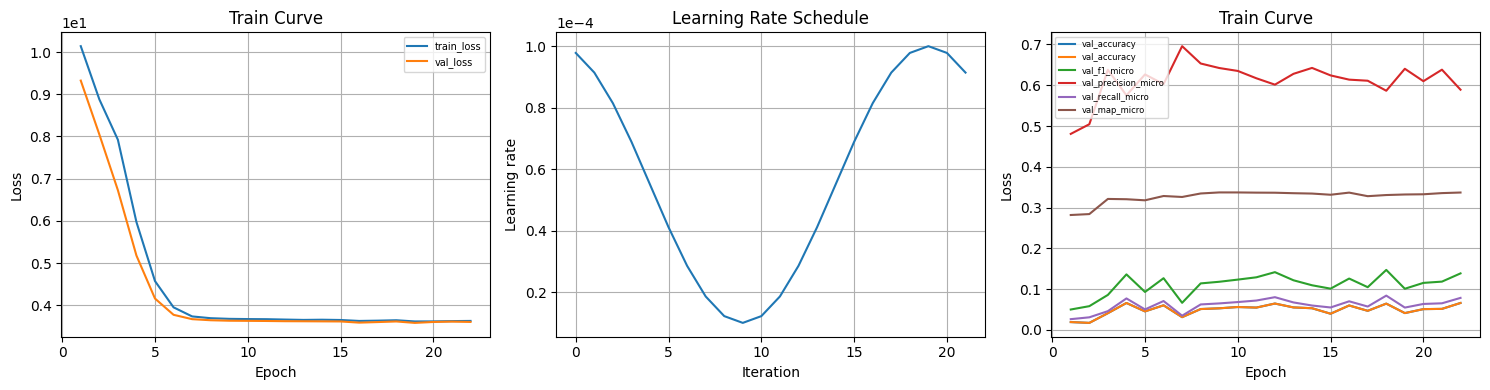

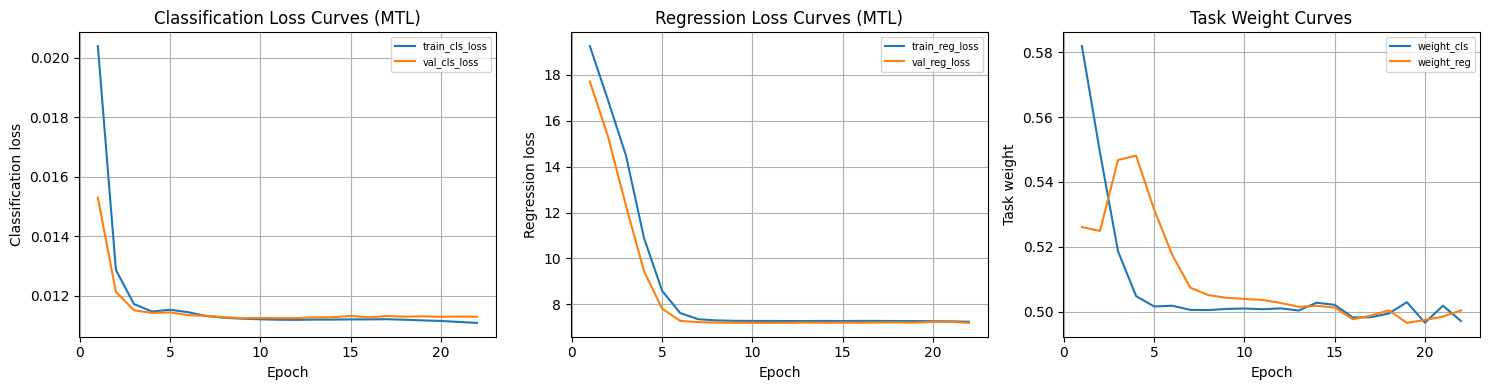

In [71]:
plot_curves(history, task="mtl")

Test features for confusion: 100%|██████████| 40/40 [00:00<00:00, 121.09it/s]


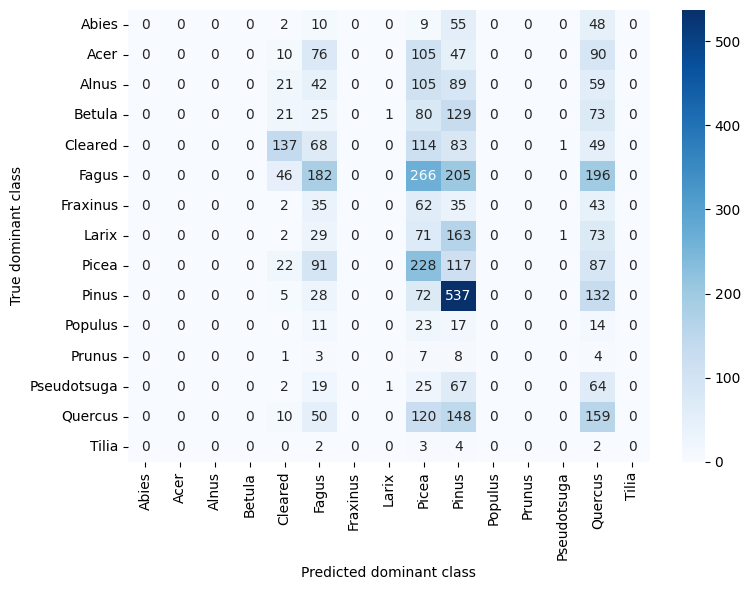

In [73]:
plot_cm(model)

Collect reg pairs: 100%|██████████| 40/40 [00:00<00:00, 119.77it/s]


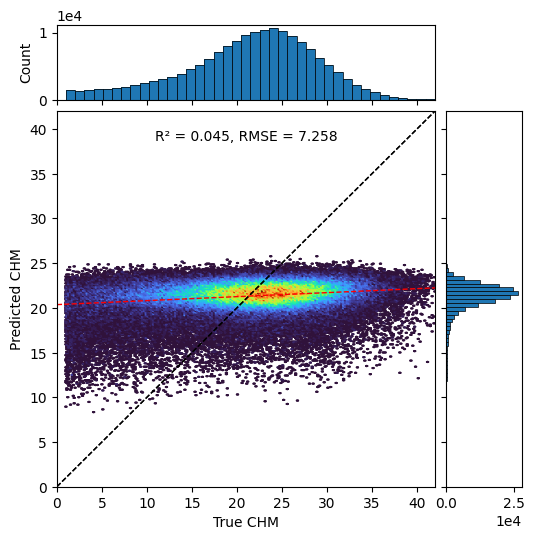

In [74]:
test_true, test_pred = collect_regression_pairs(model)
plot_regression_joint_with_hists(test_true, test_pred, max_value=42)

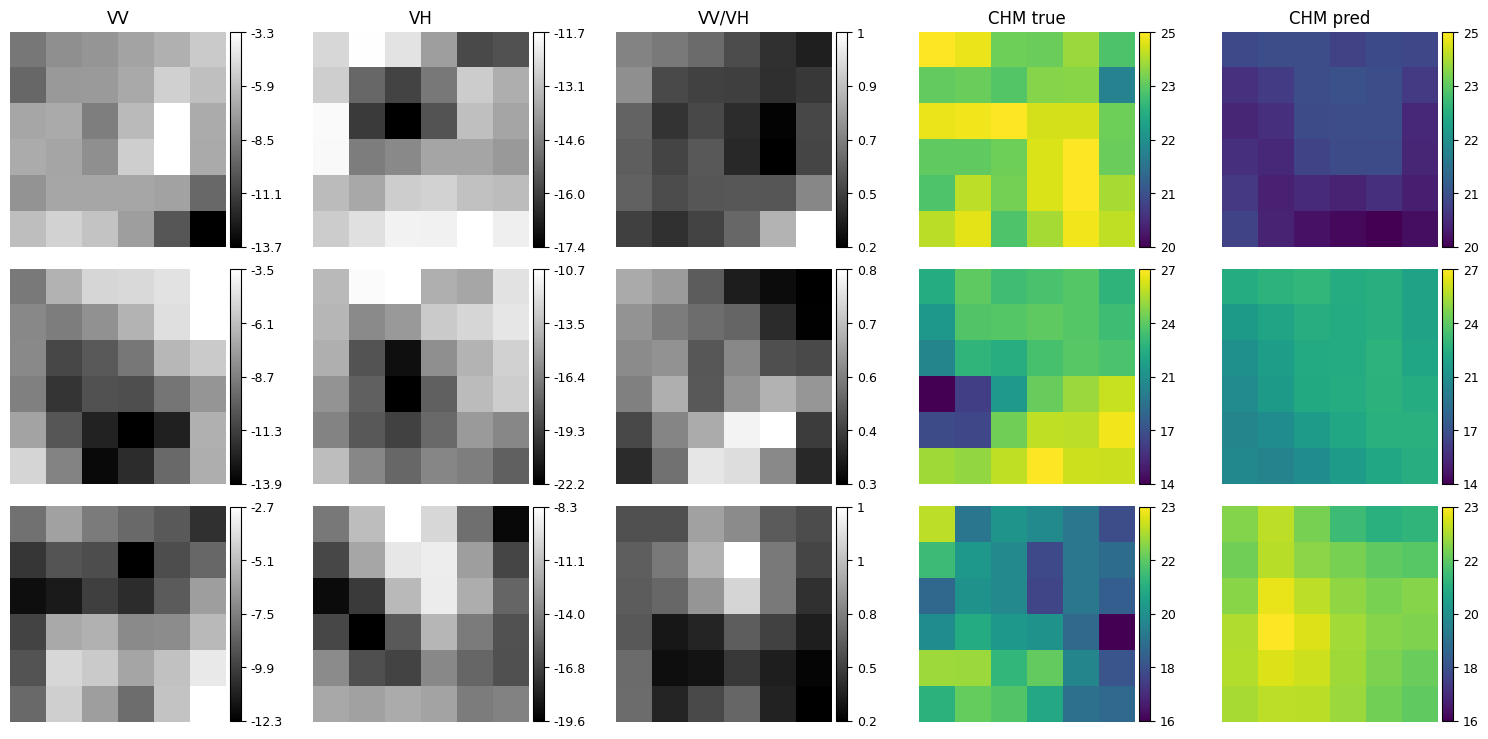

In [75]:
visualize_chm_s1_samples(model, test_ds, start_idx=42, num_samples=3)

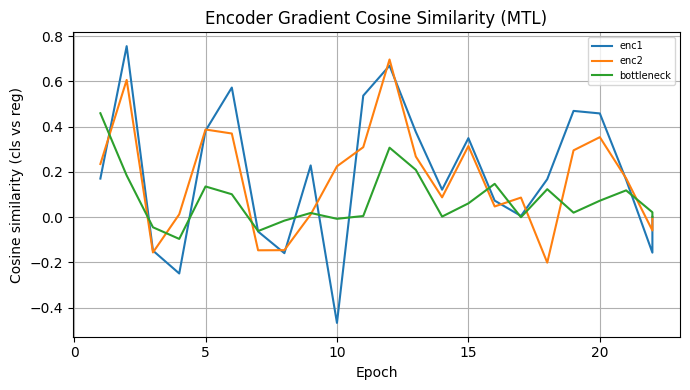

In [76]:
max_grad_batches = 100
batch_count = 100
cos_sums = {"enc1": 0.0, "enc2": 0.0, "bottleneck": 0.0}
for images, labels_cls, labels_chm in train_loader:
    cos_dict = compute_encoder_grad_cosines(
        model,
        images,
        labels_cls,
        labels_chm,
        cls_criterion,
        reg_criterion,
        device,
    )
    for k in cos_sums.keys():
        cos_sums[k] += cos_dict[k]
    batch_count += 1
    if batch_count >= max_grad_batches:
        break

if batch_count > 0:
    grad_history["epoch"].append(epoch)
    grad_history["cos_enc1"].append(cos_sums["enc1"] / batch_count)
    grad_history["cos_enc2"].append(cos_sums["enc2"] / batch_count)
    grad_history["cos_bottleneck"].append(cos_sums["bottleneck"] / batch_count)

plot_grad_cosines(grad_history)

## Cross Stitch

In [94]:
configs.update(
    model_type="MultiTaskUNetCrossStitch",
)

print(
    "model_type: ", configs["model_type"],
    "\nbase_channels: ", configs["base_channels"],
    "\nweight_decay: ", configs["weight_decay"],
    "\npatience: ", configs["patience"],
    "\ndropout: ", configs["dropout"],
    "\nepochs: ", configs["epochs"],
    "\nscheduler: ", configs["scheduler"],
    "\ncls_weight: ", configs["cls_weight"],
    "\nreg_weight: ", configs["reg_weight"],
    "\nencoder_lr: ", configs["encoder_lr"],
    "\ncls_lr: ", configs["cls_lr"],
    "\nreg_lr: ", configs["reg_lr"],
    "\nlog_lr: ", configs["log_lr"],
    "\nbase_lr: ", configs["base_lr"],
)

model_type:  MultiTaskUNetCrossStitch 
base_channels:  256 
weight_decay:  1e-05 
patience:  5 
dropout:  0.2 
epochs:  30 
scheduler:  CosineAnnealingLR 
cls_weight:  1 
reg_weight:  1 
encoder_lr:  0.0001 
cls_lr:  1e-05 
reg_lr:  0.0001 
log_lr:  0.0005 
base_lr:  1e-05


In [97]:
model = MultiTaskUNetCrossStitch(in_channels=3, num_classes=num_classes, base_channels=configs["base_channels"], dropout=configs["dropout"]).to(device)
cls_criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
reg_criterion = masked_rmse_loss
encoder_lr = configs.get("encoder_lr")
cls_lr = configs.get("cls_lr")
reg_lr = configs.get("reg_lr")
log_lr = configs.get("log_lr")
# fully-share
if configs["model_type"] == "MultiTaskUNet":
    encoder_modules = [model.enc1, model.down1, model.enc2, model.down2, model.bottleneck]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
elif configs["model_type"] == "MultiTaskUNetCrossAttention":
    # mtl-cross-attention
    encoder_modules = [
        model.enc1, model.down1, model.enc2, model.down2,
        model.bottleneck_cls, model.bottleneck_reg, model.cross_attn,
    ]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
elif configs["model_type"] == "MultiTaskUNetCrossStitch":
    encoder_modules = [
        model.enc_shared, model.enc2_cls, model.down1_cls, model.bottleneck_cls, model.down2_cls, model.enc2_reg, model.down1_reg,
        model.bottleneck_reg, model.down2_reg, model.cs_enc2, model.cs_down1, model.cs_bottleneck]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
encoder_params = collect_params(encoder_modules)
cls_params = collect_params(cls_modules)
reg_params = collect_params(reg_modules)

num_epochs = configs["epochs"]
total_steps = len(train_loader) * num_epochs
best_val_loss = 99
best_state = None
patience = configs["patience"]
epochs_no_improve = 0
scheduler = None
history = {key: [] for key in history}
grad_history = {key: [] for key in grad_history}

log_vars = torch.nn.Parameter(torch.zeros(2, device=device))
optimizer = torch.optim.AdamW(
    [
        {"params": encoder_params, "lr": encoder_lr, "weight_decay": configs["weight_decay"]},
        {"params": cls_params,     "lr": cls_lr,     "weight_decay": configs["weight_decay"]},
        {"params": reg_params,     "lr": reg_lr,     "weight_decay": configs["weight_decay"]},
        {"params": [log_vars],     "lr": log_lr,     "weight_decay": 0.0},
    ]
)

if configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps//2,
        eta_min=configs["base_lr"],
    )
else:
    scheduler = None

In [98]:
for epoch in range(1, num_epochs + 1):
    train_loss, train_cls_loss, train_reg_loss = train_one_epoch(
        model, train_loader, cls_criterion, reg_criterion,
        optimizer, device,
        epoch=epoch,
        scheduler=scheduler,
        cls_weight=configs["cls_weight"],
        reg_weight=configs["reg_weight"],
        log_vars=log_vars,
    )
    val_metrics, _, _ = evaluate(
        model, val_loader, cls_criterion, reg_criterion,
        device, desc="Val",
        cls_weight=configs["cls_weight"], reg_weight=configs["reg_weight"], log_vars=log_vars,
    )
    w_cls_eff = 0.5 * torch.exp(-log_vars[0]).item()
    w_reg_eff = 0.5 * torch.exp(-log_vars[1]).item()
    print(f"Epoch {epoch}: Train total {train_loss:.4f}, cls: {train_cls_loss:.4f}, reg: {train_reg_loss:.4f}")
    print(
        "\tVal total: {loss:.4f}, cls: {cls_loss:.4f}, reg: {reg_loss:.4f}, \n"
        "\taccuracy: {accuracy:.4f}, r2: {r2:.4f},".format(**val_metrics),
        f"\n\tw_cls: {w_cls_eff:.4f}, w_reg: {w_reg_eff:.4f}"
    )
    _update_history(history, epoch, train_loss, train_cls_loss, train_reg_loss, val_metrics, w_cls_eff, w_reg_eff)

    max_grad_batches = 1
    batch_count = 0
    cos_sums = {"enc1": 0.0, "enc2": 0.0, "bottleneck": 0.0}
    for images, labels_cls, labels_chm in train_loader:
        cos_dict = compute_encoder_grad_cosines(
            model,
            images,
            labels_cls,
            labels_chm,
            cls_criterion,
            reg_criterion,
            device,
        )
        for k in cos_sums.keys():
            cos_sums[k] += cos_dict[k]
        batch_count += 1
        if batch_count >= max_grad_batches:
            break

    if batch_count > 0:
        grad_history["epoch"].append(epoch)
        grad_history["cos_enc1"].append(cos_sums["enc1"] / batch_count)
        grad_history["cos_enc2"].append(cos_sums["enc2"] / batch_count)
        grad_history["cos_bottleneck"].append(cos_sums["bottleneck"] / batch_count)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = round(val_metrics["loss"], 5)
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"\tPatience {epochs_no_improve}/{patience} ")
    if epochs_no_improve >= patience:
        print("\tEarly stopping triggered after", epoch, "epochs")
        break

Val: 100%|██████████| 40/40 [00:00<00:00, 94.47it/s] 

Epoch 1: Train total 0.8649, cls: 0.0216, reg: 19.5806
	Val total: 0.9695, cls: 0.0150, reg: 18.2533, 
	accuracy: 0.0284, r2: -5.2920, 
	w_cls: 0.5838, w_reg: 0.5227


	Updated best model


Val: 100%|██████████| 40/40 [00:00<00:00, 95.59it/s] 

Epoch 2: Train total 0.9546, cls: 0.0131, reg: 17.4507
	Val total: 0.9344, cls: 0.0120, reg: 15.5124, 
	accuracy: 0.0709, r2: -3.5532, 
	w_cls: 0.5527, w_reg: 0.5266


...

Val: 100%|██████████| 40/40 [00:00<00:00, 95.92it/s] 

Epoch 29: Train total 0.9918, cls: 0.0022, reg: 4.1892
	Val total: 0.8822, cls: 0.0180, reg: 8.2778, 
	accuracy: 0.1014, r2: -0.2576, 
	w_cls: 0.5028, w_reg: 0.4999


	Patience 1/5 


Val: 100%|██████████| 40/40 [00:00<00:00, 92.82it/s] 


Epoch 30: Train total 0.9893, cls: 0.0014, reg: 3.9786
	Val total: 0.8840, cls: 0.0190, reg: 8.1765, 
	accuracy: 0.1151, r2: -0.2285, 
	w_cls: 0.5030, w_reg: 0.5001
	Patience 2/5 


In [99]:
inference_mtl(model, best_state, cls_criterion=cls_criterion, reg_criterion=reg_criterion, device=device)

Test Eval: 100%|██████████| 40/40 [00:00<00:00, 88.69it/s]


test loss:  1.7933 
cls loss:  0.0195 
reg loss:  8.1644 
r2:  -0.2130

               precision    recall  f1-score   support

       Abies       0.00      0.00      0.00       124
        Acer       0.14      0.05      0.07       328
       Alnus       0.04      0.02      0.02       329
      Betula       0.05      0.02      0.03       357
     Cleared       0.44      0.31      0.36       567
       Fagus       0.28      0.25      0.27      1142
    Fraxinus       0.12      0.04      0.05       285
       Larix       0.11      0.06      0.08       491
       Picea       0.32      0.31      0.31      1101
       Pinus       0.42      0.40      0.41      1160
     Populus       0.00      0.00      0.00        89
      Prunus       0.00      0.00      0.00        38
 Pseudotsuga       0.13      0.05      0.07       450
     Quercus       0.29      0.26      0.27      1151
       Tilia       0.00      0.00      0.00        27

   micro avg       0.30      0.22      0.25      7639
   macr

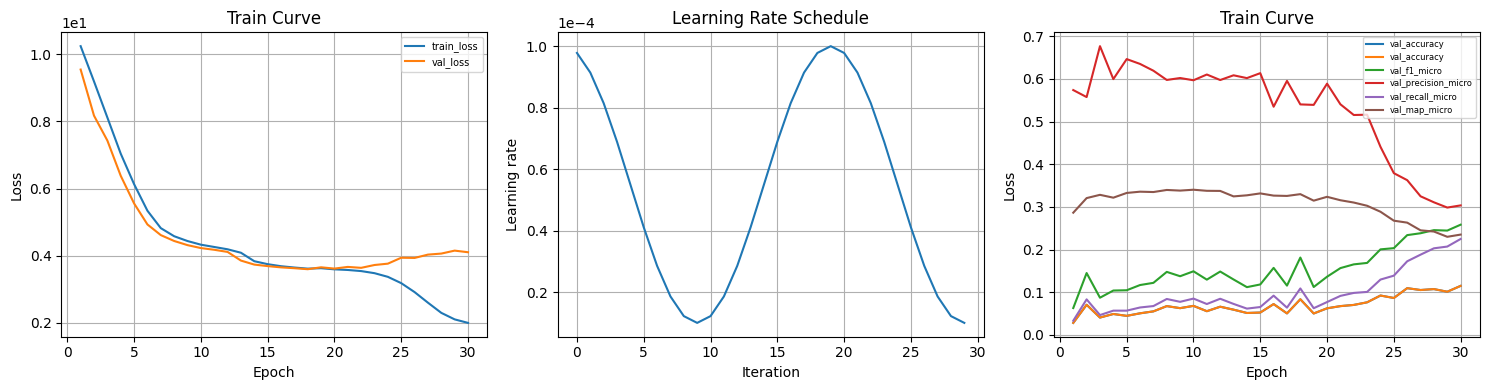

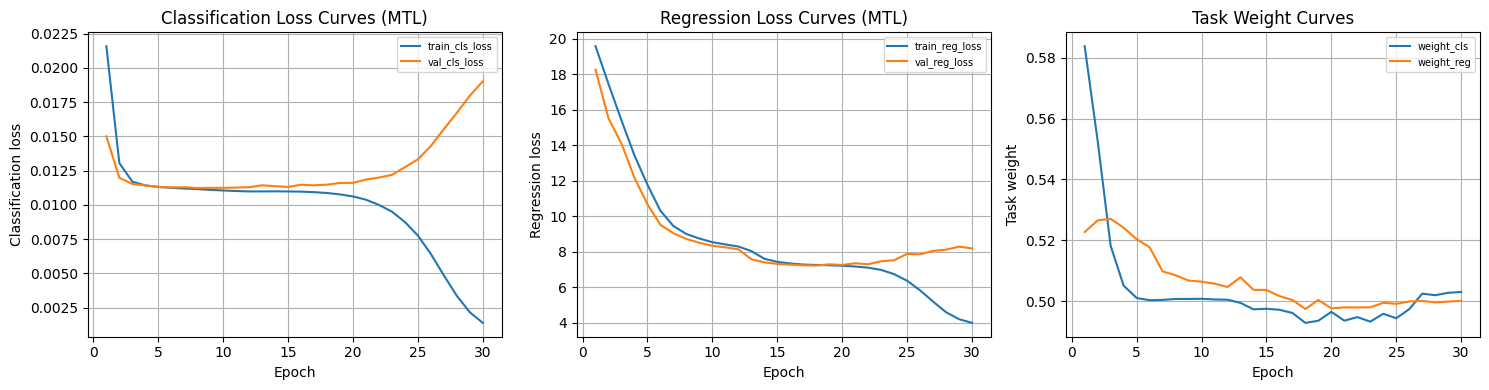

In [100]:
plot_curves(history, task="mtl")

Test features for confusion: 100%|██████████| 40/40 [00:00<00:00, 101.82it/s]


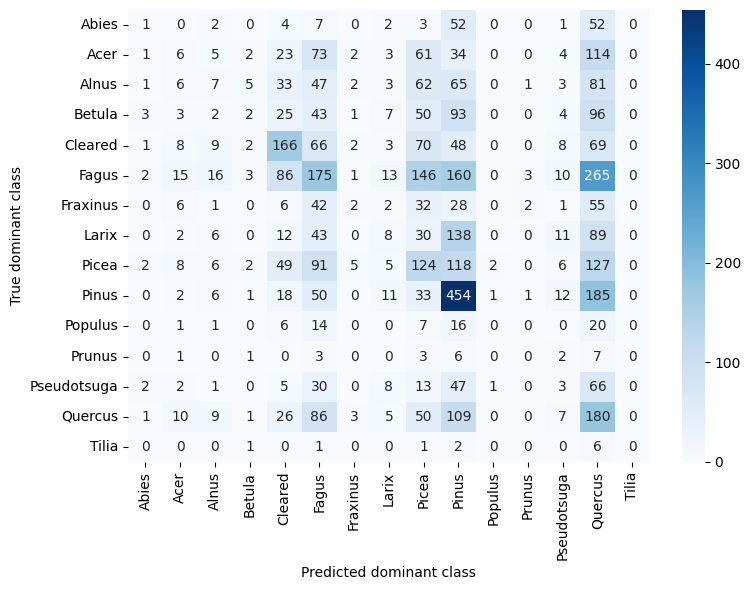

In [86]:
plot_cm(model)

Collect reg pairs: 100%|██████████| 40/40 [00:00<00:00, 88.83it/s] 


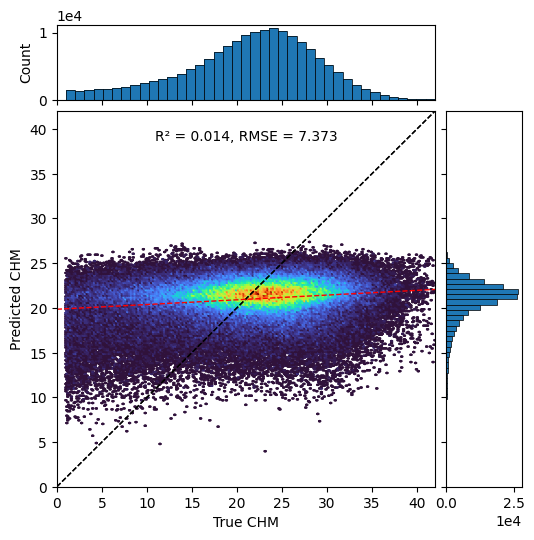

In [87]:
test_true, test_pred = collect_regression_pairs(model)
plot_regression_joint_with_hists(test_true, test_pred, max_value=42)

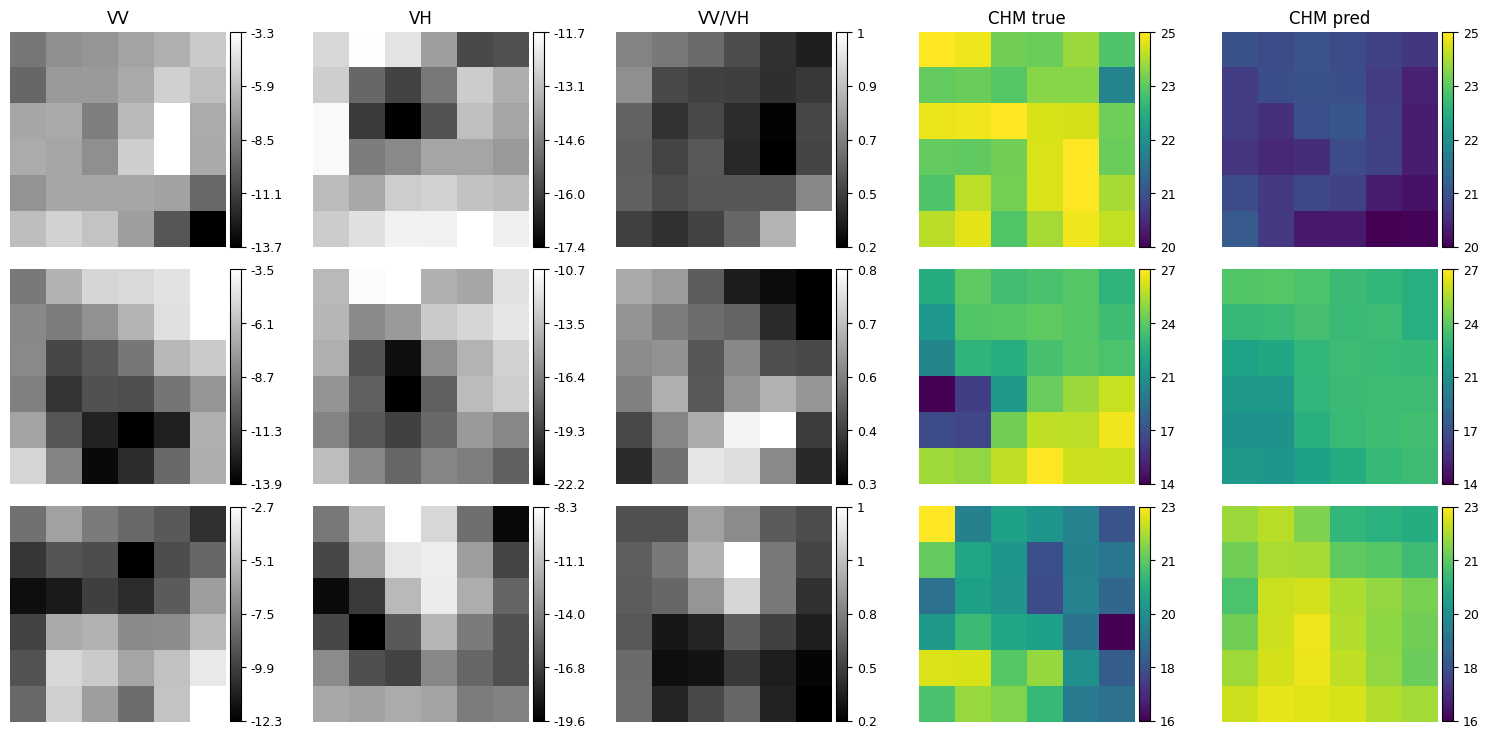

In [88]:
visualize_chm_s1_samples(model, test_ds, start_idx=42, num_samples=3)

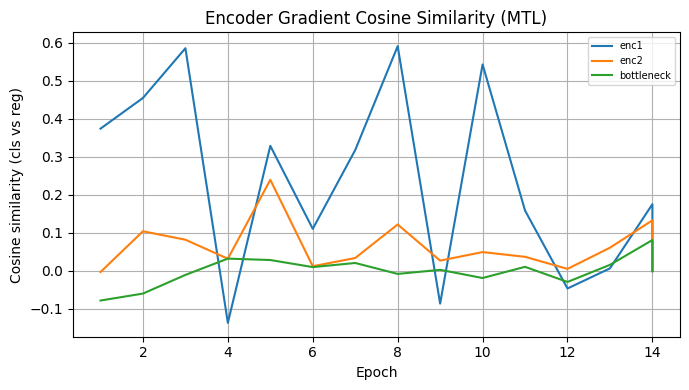

In [90]:
batch_count = 100
cos_sums = {"enc1": 0.0, "enc2": 0.0, "bottleneck": 0.0}
for images, labels_cls, labels_chm in train_loader:
    cos_dict = compute_encoder_grad_cosines(
        model,
        images,
        labels_cls,
        labels_chm,
        cls_criterion,
        reg_criterion,
        device,
    )
    for k in cos_sums.keys():
        cos_sums[k] += cos_dict[k]
    batch_count += 1
    if batch_count >= max_grad_batches:
        break

if batch_count > 0:
    grad_history["epoch"].append(epoch)
    grad_history["cos_enc1"].append(cos_sums["enc1"] / batch_count)
    grad_history["cos_enc2"].append(cos_sums["enc2"] / batch_count)
    grad_history["cos_bottleneck"].append(cos_sums["bottleneck"] / batch_count)

plot_grad_cosines(grad_history)

## Cross Attention

In [101]:
configs.update(
    model_type="MultiTaskUNetCrossAttention",
)

print(
    "model_type: ", configs["model_type"],
    "\nbase_channels: ", configs["base_channels"],
    "\nweight_decay: ", configs["weight_decay"],
    "\npatience: ", configs["patience"],
    "\ndropout: ", configs["dropout"],
    "\nepochs: ", configs["epochs"],
    "\nscheduler: ", configs["scheduler"],
    "\ncls_weight: ", configs["cls_weight"],
    "\nreg_weight: ", configs["reg_weight"],
    "\nencoder_lr: ", configs["encoder_lr"],
    "\ncls_lr: ", configs["cls_lr"],
    "\nreg_lr: ", configs["reg_lr"],
    "\nlog_lr: ", configs["log_lr"],
    "\nbase_lr: ", configs["base_lr"],
)

model_type:  MultiTaskUNetCrossAttention 
base_channels:  256 
weight_decay:  1e-05 
patience:  5 
dropout:  0.2 
epochs:  30 
scheduler:  CosineAnnealingLR 
cls_weight:  1 
reg_weight:  1 
encoder_lr:  0.0001 
cls_lr:  1e-05 
reg_lr:  0.0001 
log_lr:  0.0005 
base_lr:  1e-05


In [102]:
model = MultiTaskUNetCrossAttention(in_channels=3, num_classes=num_classes, base_channels=configs["base_channels"], dropout=configs["dropout"]).to(device)
cls_criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
reg_criterion = masked_rmse_loss
encoder_lr = configs.get("encoder_lr")
cls_lr = configs.get("cls_lr")
reg_lr = configs.get("reg_lr")
log_lr = configs.get("log_lr")
# fully-share
if configs["model_type"] == "MultiTaskUNet":
    encoder_modules = [model.enc1, model.down1, model.enc2, model.down2, model.bottleneck]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
elif configs["model_type"] == "MultiTaskUNetCrossAttention":
    # mtl-cross-attention
    encoder_modules = [
        model.enc1, model.down1, model.enc2, model.down2,
        model.bottleneck_cls, model.bottleneck_reg, model.cross_attn,
    ]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
elif configs["model_type"] == "MultiTaskUNetCrossStitch":
    encoder_modules = [
        model.enc_shared, model.enc2_cls, model.down1_cls, model.bottleneck_cls, model.down2_cls, model.enc2_reg, model.down1_reg,
        model.bottleneck_reg, model.down2_reg, model.cs_enc2, model.cs_down1, model.cs_bottleneck]
    cls_modules = [model.global_pool_cls, model.cls_head]
    reg_modules = [model.up2_reg, model.dropout2_reg, model.up1_reg, model.out_conv_reg]
encoder_params = collect_params(encoder_modules)
cls_params = collect_params(cls_modules)
reg_params = collect_params(reg_modules)

num_epochs = configs["epochs"]
total_steps = len(train_loader) * num_epochs
best_val_loss = 99
best_state = None
patience = configs["patience"]
epochs_no_improve = 0
scheduler = None
history = {key: [] for key in history}
grad_history = {key: [] for key in grad_history}

log_vars = torch.nn.Parameter(torch.zeros(2, device=device))
optimizer = torch.optim.AdamW(
    [
        {"params": encoder_params, "lr": encoder_lr, "weight_decay": configs["weight_decay"]},
        {"params": cls_params,     "lr": cls_lr,     "weight_decay": configs["weight_decay"]},
        {"params": reg_params,     "lr": reg_lr,     "weight_decay": configs["weight_decay"]},
        {"params": [log_vars],     "lr": log_lr,     "weight_decay": 0.0},
    ]
)

if configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps//2,
        eta_min=configs["base_lr"],
    )
else:
    scheduler = None

In [103]:
for epoch in range(1, num_epochs + 1):
    train_loss, train_cls_loss, train_reg_loss = train_one_epoch(
        model, train_loader, cls_criterion, reg_criterion,
        optimizer, device,
        epoch=epoch,
        scheduler=scheduler,
        cls_weight=configs["cls_weight"],
        reg_weight=configs["reg_weight"],
        log_vars=log_vars,
    )
    val_metrics, _, _ = evaluate(
        model, val_loader, cls_criterion, reg_criterion,
        device, desc="Val",
        cls_weight=configs["cls_weight"], reg_weight=configs["reg_weight"], log_vars=log_vars,
    )
    w_cls_eff = 0.5 * torch.exp(-log_vars[0]).item()
    w_reg_eff = 0.5 * torch.exp(-log_vars[1]).item()
    print(f"Epoch {epoch}: Train total {train_loss:.4f}, cls: {train_cls_loss:.4f}, reg: {train_reg_loss:.4f}")
    print(
        "\tVal total: {loss:.4f}, cls: {cls_loss:.4f}, reg: {reg_loss:.4f}, \n"
        "\taccuracy: {accuracy:.4f}, r2: {r2:.4f},".format(**val_metrics),
        f"\n\tw_cls: {w_cls_eff:.4f}, w_reg: {w_reg_eff:.4f}"
    )
    _update_history(history, epoch, train_loss, train_cls_loss, train_reg_loss, val_metrics, w_cls_eff, w_reg_eff)

    max_grad_batches = 1
    batch_count = 0
    cos_sums = {"enc1": 0.0, "enc2": 0.0, "bottleneck": 0.0}
    for images, labels_cls, labels_chm in train_loader:
        cos_dict = compute_encoder_grad_cosines(
            model,
            images,
            labels_cls,
            labels_chm,
            cls_criterion,
            reg_criterion,
            device,
        )
        for k in cos_sums.keys():
            cos_sums[k] += cos_dict[k]
        batch_count += 1
        if batch_count >= max_grad_batches:
            break

    if batch_count > 0:
        grad_history["epoch"].append(epoch)
        grad_history["cos_enc1"].append(cos_sums["enc1"] / batch_count)
        grad_history["cos_enc2"].append(cos_sums["enc2"] / batch_count)
        grad_history["cos_bottleneck"].append(cos_sums["bottleneck"] / batch_count)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = round(val_metrics["loss"], 5)
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"\tPatience {epochs_no_improve}/{patience} ")
    if epochs_no_improve >= patience:
        print("\tEarly stopping triggered after", epoch, "epochs")
        break

Val: 100%|██████████| 40/40 [00:00<00:00, 91.34it/s] 


Epoch 1: Train total 0.9136, cls: 0.0122, reg: 19.7771
	Val total: 0.9207, cls: 0.0115, reg: 17.7432, 
	accuracy: 0.0443, r2: -4.9421, 
	w_cls: 0.5290, w_reg: 0.5235
	Updated best model


Val: 100%|██████████| 40/40 [00:00<00:00, 92.47it/s] 

Epoch 2: Train total 0.9898, cls: 0.0116, reg: 17.6343
	Val total: 0.9210, cls: 0.0123, reg: 17.2345, 
	accuracy: 0.0899, r2: -4.6156, 
	w_cls: 0.5056, w_reg: 0.5255


	Patience 1/5 


...

Val: 100%|██████████| 40/40 [00:00<00:00, 97.19it/s] 


Epoch 16: Train total 0.9975, cls: 0.0113, reg: 7.2857
	Val total: 0.8983, cls: 0.0113, reg: 7.2092, 
	accuracy: 0.0462, r2: 0.0354, 
	w_cls: 0.4998, w_reg: 0.5001
	Patience 4/5 


Val: 100%|██████████| 40/40 [00:00<00:00, 93.79it/s] 

Epoch 17: Train total 1.0015, cls: 0.0113, reg: 7.2821
	Val total: 0.8975, cls: 0.0113, reg: 7.2066, 
	accuracy: 0.0554, r2: 0.0359, 
	w_cls: 0.4996, w_reg: 0.5002


	Patience 5/5 
	Early stopping triggered after 17 epochs


In [104]:
inference_mtl(model, best_state, cls_criterion=cls_criterion, reg_criterion=reg_criterion, device=device)

Test Eval: 100%|██████████| 40/40 [00:00<00:00, 90.95it/s] 


test loss:  1.8189 
cls loss:  0.0116 
reg loss:  7.2428 
r2:  0.0370

               precision    recall  f1-score   support

       Abies       0.00      0.00      0.00       124
        Acer       0.00      0.00      0.00       328
       Alnus       0.00      0.00      0.00       329
      Betula       0.00      0.00      0.00       357
     Cleared       0.63      0.23      0.34       567
       Fagus       0.71      0.01      0.02      1142
    Fraxinus       0.00      0.00      0.00       285
       Larix       0.00      0.00      0.00       491
       Picea       0.53      0.01      0.02      1101
       Pinus       0.60      0.31      0.41      1160
     Populus       0.00      0.00      0.00        89
      Prunus       0.00      0.00      0.00        38
 Pseudotsuga       0.00      0.00      0.00       450
     Quercus       0.00      0.00      0.00      1151
       Tilia       0.00      0.00      0.00        27

   micro avg       0.61      0.07      0.12      7639
   macro

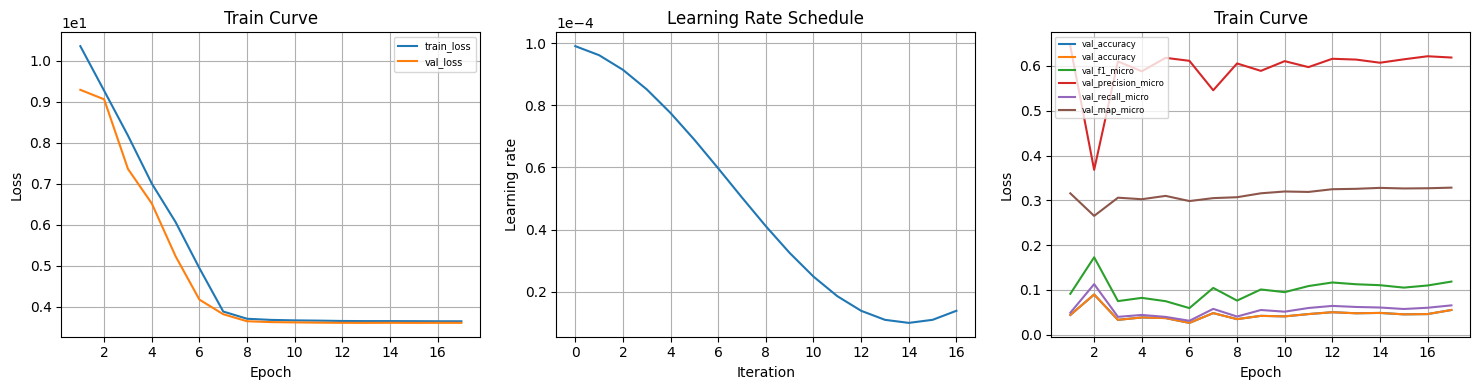

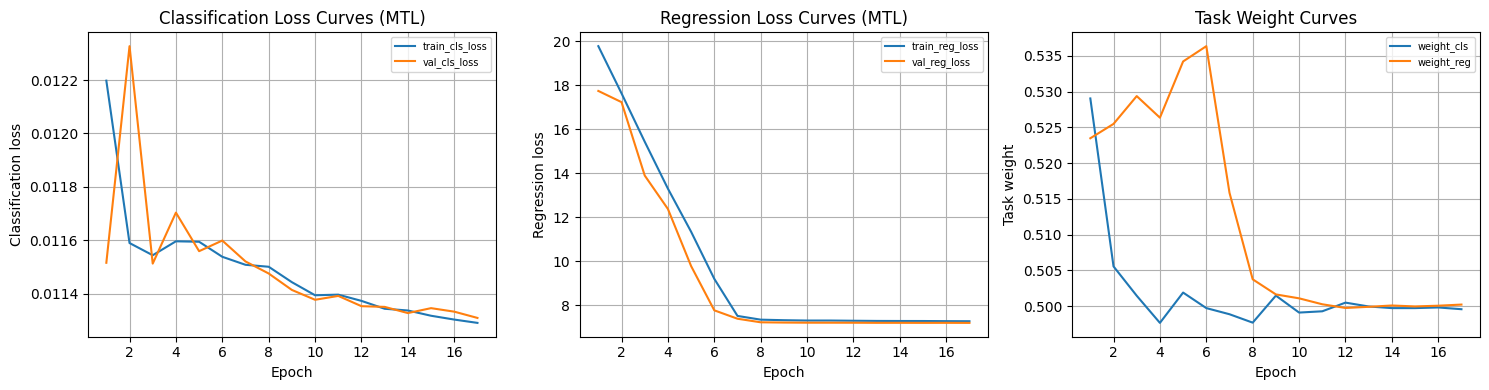

In [105]:
plot_curves(history, task="mtl")

Test features for confusion: 100%|██████████| 40/40 [00:00<00:00, 102.64it/s]


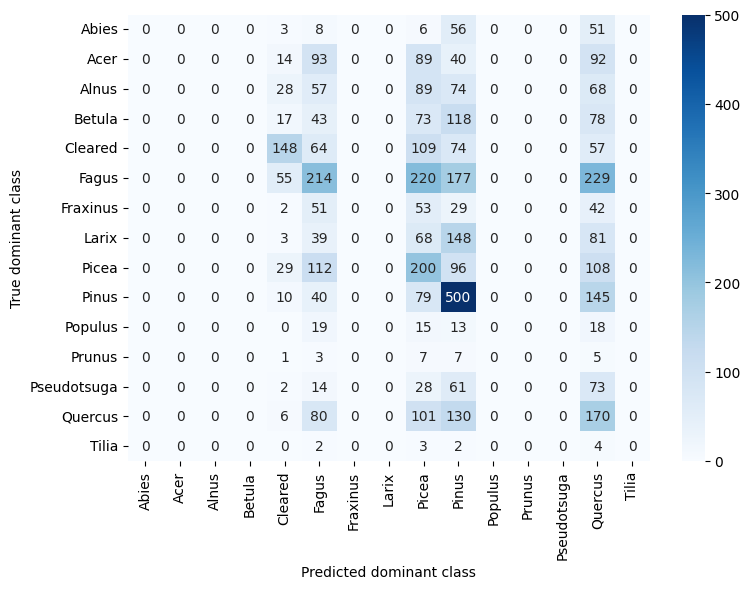

In [106]:
plot_cm(model)

Collect reg pairs: 100%|██████████| 40/40 [00:00<00:00, 102.62it/s]


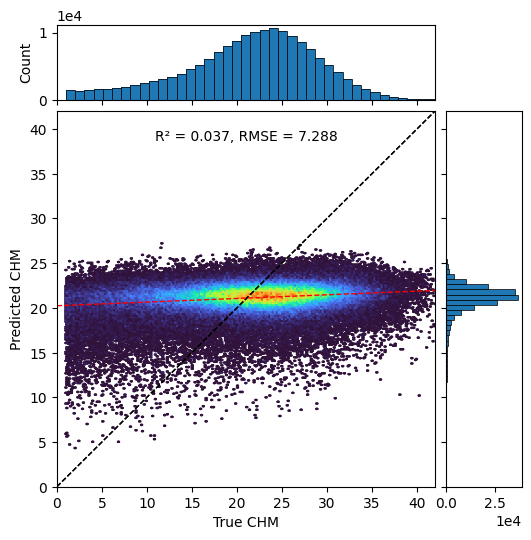

In [107]:
test_true, test_pred = collect_regression_pairs(model)
plot_regression_joint_with_hists(test_true, test_pred, max_value=42)

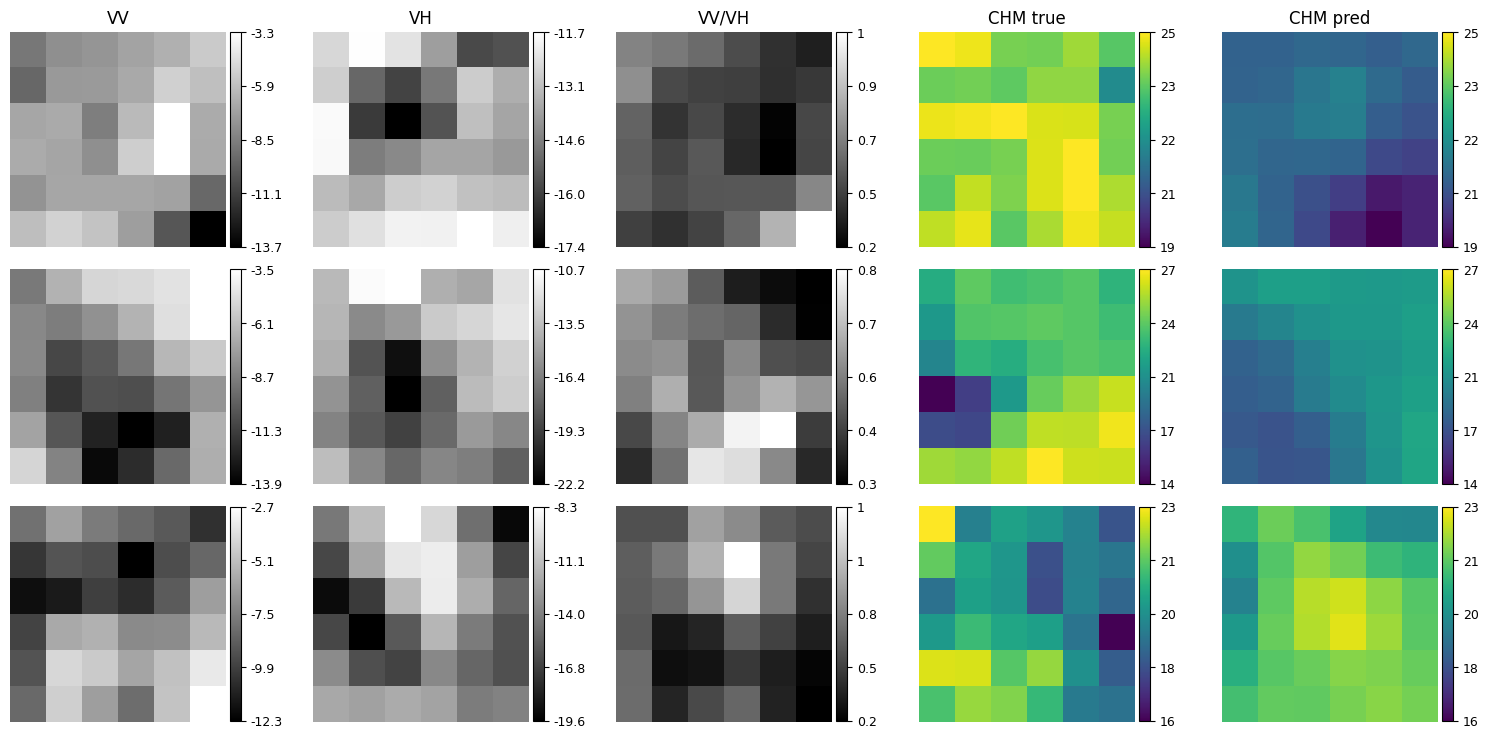

In [108]:
visualize_chm_s1_samples(model, test_ds, start_idx=42, num_samples=3)

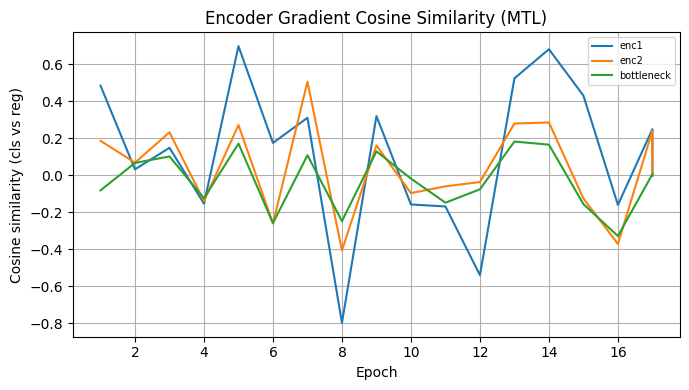

In [109]:
max_grad_batches = 100
batch_count = 100
cos_sums = {"enc1": 0.0, "enc2": 0.0, "bottleneck": 0.0}
for images, labels_cls, labels_chm in train_loader:
    cos_dict = compute_encoder_grad_cosines(
        model,
        images,
        labels_cls,
        labels_chm,
        cls_criterion,
        reg_criterion,
        device,
    )
    for k in cos_sums.keys():
        cos_sums[k] += cos_dict[k]
    batch_count += 1
    if batch_count >= max_grad_batches:
        break

if batch_count > 0:
    grad_history["epoch"].append(epoch)
    grad_history["cos_enc1"].append(cos_sums["enc1"] / batch_count)
    grad_history["cos_enc2"].append(cos_sums["enc2"] / batch_count)
    grad_history["cos_bottleneck"].append(cos_sums["bottleneck"] / batch_count)

plot_grad_cosines(grad_history)